# Big Data Analysis and Application Practice

**Practice Topic:** Linear Regression Mini Practice  
**School:** Hubei University  
**Class:** Software Engineering 2402  
**Student Name:** Qin Tian  
**Student ID:** 21907869  
**Instructor:** Li Jie

# Part 1. Practice Goal

This notebook is a small practice on linear regression. One dataset is used for single-variable regression, and the other one is used for multi-variable regression.

The main purpose is to go through the basic workflow and make a simple comparison between manual implementation and common library methods.

# Part 2. Data Overview

This notebook uses two files: `regress_data1.csv` and `regress_data2.csv`. The first file contains `人口` and `收益`, and the second file contains `面积`, `房间数`, and `价格`.

Before training, I only do a few simple checks such as shape, columns, and missing values.

# Part 3. Main Steps

First, I read the data and check the basic information. Then I build the cost function and batch gradient descent, and use them to fit the regression model.

After that, I standardize the multi-variable data and make a simple comparison with `LinearRegression`, `Ridge`, `Lasso`, and the least squares method.

# Part 4. Code and Notes

## 4.1 Import libraries and read the data

Import the needed packages and read the two csv files.

In [2]:
# Import the libraries needed for the experiment and read in two regression datasets.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

data1 = pd.read_csv('regress_data1.csv', encoding='utf-8')
data2 = pd.read_csv('regress_data2.csv', encoding='utf-8')

print('data1 shape:', data1.shape)
print('data2 shape:', data2.shape)
data1.head()

data1 shape: (97, 2)
data2 shape: (47, 3)


,人口,收益
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


## 4.2 Check basic information and missing values

Take a quick look at the data structure and make sure there is no obvious missing-value problem.

In [3]:
# Examine the structure, statistical information, and missing value conditions of the two datasets.
print('Data1 info:')
data1.info()
print('\nData1 missing values:')
print(data1.isnull().sum())
print('\nData1 describe:')
display(data1.describe())

print('Data2 info:')
data2.info()
print('\nData2 missing values:')
print(data2.isnull().sum())
print('\nData2 describe:')
display(data2.describe())

Data1 info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   人口      97 non-null     float64
 1   收益      97 non-null     float64
dtypes: float64(2)
memory usage: 1.6 KB

Data1 missing values:
人口    0
收益    0
dtype: int64

Data1 describe:


,人口,收益
count,97.000000,97.000000
mean,8.159800,5.839135
std,3.869884,5.510262
min,5.026900,-2.680700
25%,5.707700,1.986900
50%,6.589400,4.562300
75%,8.578100,7.046700
max,22.203000,24.147000


Data2 info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   面积      47 non-null     int64
 1   房间数     47 non-null     int64
 2   价格      47 non-null     int64
dtypes: int64(3)
memory usage: 1.2 KB

Data2 missing values:
面积     0
房间数    0
价格     0
dtype: int64

Data2 describe:


,面积,房间数,价格
count,47.000000,47.000000,47.000000
mean,2000.680851,3.170213,340412.659574
std,794.702354,0.760982,125039.899586
min,852.000000,1.000000,169900.000000
25%,1432.000000,3.000000,249900.000000
50%,1888.000000,3.000000,299900.000000
75%,2269.000000,4.000000,384450.000000
max,4478.000000,5.000000,699900.000000


## 4.3 Plot the single-variable data

Use a scatter plot to see whether population and profit look roughly linear.

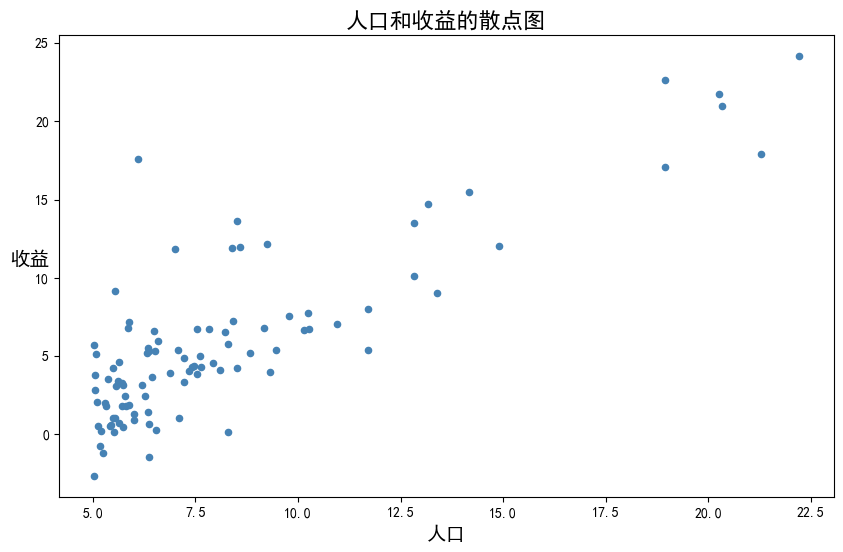

In [4]:
# First, draw a scatter plot of the univariate data to visually observe the linear relationship.
data1.plot(kind='scatter', x='人口', y='收益', figsize=(10, 6), color='steelblue')
plt.xlabel('人口', fontsize=14)
plt.ylabel('收益', fontsize=14, rotation=0)
plt.title('人口和收益的散点图', fontsize=16)
plt.show()

## 4.4 Build the cost function

Add the intercept term and define the cost function for later training.

In [5]:
# Define the cost function of linear regression and prepare the single-variable training data
def compute_cost(X, y, w):
    inner = np.power((X @ w.T) - y, 2)
    return np.sum(inner) / (2 * X.shape[0])

data1_gd = data1.copy()
data1_gd.insert(0, 'Ones', 1)
cols = data1_gd.shape[1]
X1 = np.matrix(data1_gd.iloc[:, :cols-1].values)
y1 = np.matrix(data1_gd.iloc[:, cols-1:cols].values)
w1 = np.matrix(np.zeros((1, X1.shape[1])))

print('X1 shape:', X1.shape)
print('y1 shape:', y1.shape)
print('w1 shape:', w1.shape)
print('Initial cost:', compute_cost(X1, y1, w1))

X1 shape: (97, 2)
y1 shape: (97, 1)
w1 shape: (1, 2)
Initial cost: 32.072733877455676


## 4.5 Implement batch gradient descent

Update the parameters again and again, so the cost can gradually decrease.

In [6]:
# Define the batch gradient descent function to continuously update the parameters
def batch_gradient_descent(X, y, w, alpha, iters):
    temp = np.matrix(np.zeros(w.shape))
    parameters = w.shape[1]
    cost = np.zeros(iters)

    for i in range(iters):
        error = (X @ w.T) - y
        for j in range(parameters):
            term = np.multiply(error, X[:, j])
            temp[0, j] = w[0, j] - (alpha / len(X)) * np.sum(term)
        w = temp.copy()
        cost[i] = compute_cost(X, y, w)

    return w, cost

## 4.6 Train the single-variable model

Train the model, then look at the fitted line and the cost curve.

Single-variable parameters: [[-3.24140214  1.1272942 ]]
Single-variable final cost: 4.515955503078914


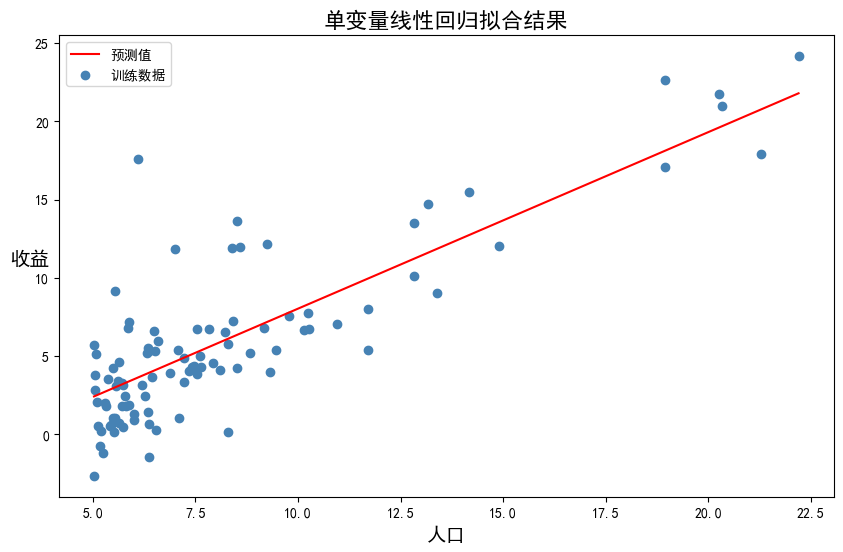

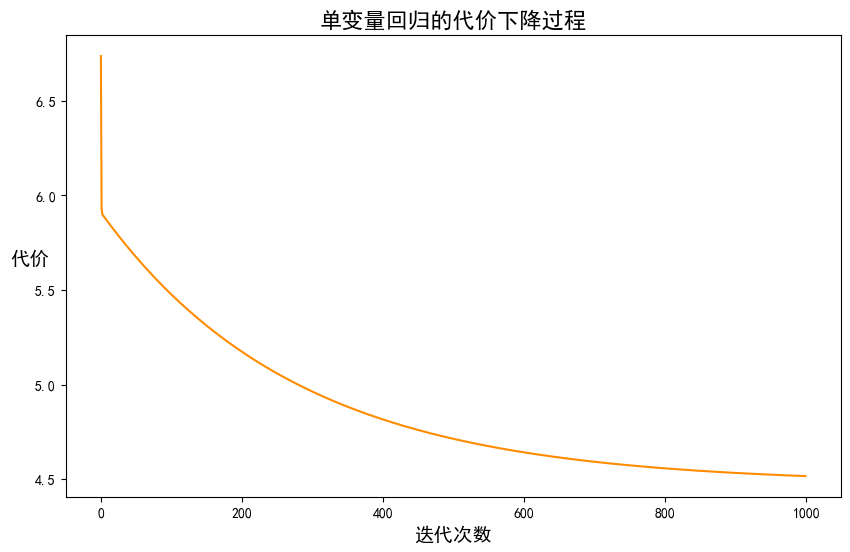

In [7]:
# Train a single-variable linear regression model and observe the fitting curve and the process of cost reduction.
alpha = 0.01
iters = 1000
g1, cost1 = batch_gradient_descent(X1, y1, w1, alpha, iters)
print('Single-variable parameters:', g1)
print('Single-variable final cost:', compute_cost(X1, y1, g1))

x = np.linspace(data1['人口'].min(), data1['人口'].max(), 100)
f = g1[0, 0] + g1[0, 1] * x

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, f, 'r', label='预测值')
ax.scatter(data1['人口'], data1['收益'], label='训练数据', color='steelblue')
ax.legend(loc=2)
ax.set_xlabel('人口', fontsize=14)
ax.set_ylabel('收益', fontsize=14, rotation=0)
ax.set_title('单变量线性回归拟合结果', fontsize=16)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.arange(iters), cost1, 'darkorange')
ax.set_xlabel('迭代次数', fontsize=14)
ax.set_ylabel('代价', fontsize=14, rotation=0)
ax.set_title('单变量回归的代价下降过程', fontsize=16)
plt.show()

## 4.7 Standardize the multi-variable data

The feature scales are different, so I standardize them before training.

In [ ]:
# Standardize the multivariable data and prepare training data with many variables
data2_norm = (data2 - data2.mean()) / data2.std()
display(data2_norm.head())

data2_gd = data2_norm.copy()
data2_gd.insert(0, 'Ones', 1)
cols2 = data2_gd.shape[1]
X2 = np.matrix(data2_gd.iloc[:, :cols2-1].values)
y2 = np.matrix(data2_gd.iloc[:, cols2-1:cols2].values)
w2 = np.matrix(np.zeros((1, X2.shape[1])))

print('X2 shape:', X2.shape)
print('y2 shape:', y2.shape)
print('Initial cost for data2:', compute_cost(X2, y2, w2))

,面积,房间数,价格
0,0.130010,-0.223675,0.475747
1,-0.504190,-0.223675,-0.084074
2,0.502476,-0.223675,0.228626
3,-0.735723,-1.537767,-0.867025
4,1.257476,1.090417,1.595389


X2 shape: (47, 3)
y2 shape: (47, 1)
Initial cost for data2: 0.4893617021276595


## 4.8 Train the multi-variable model

Use the same gradient descent method on the standardized housing data.

Multi-variable parameters: [[-1.10898288e-16  8.78503652e-01 -4.69166570e-02]]
Multi-variable final cost: 0.13070336960771892


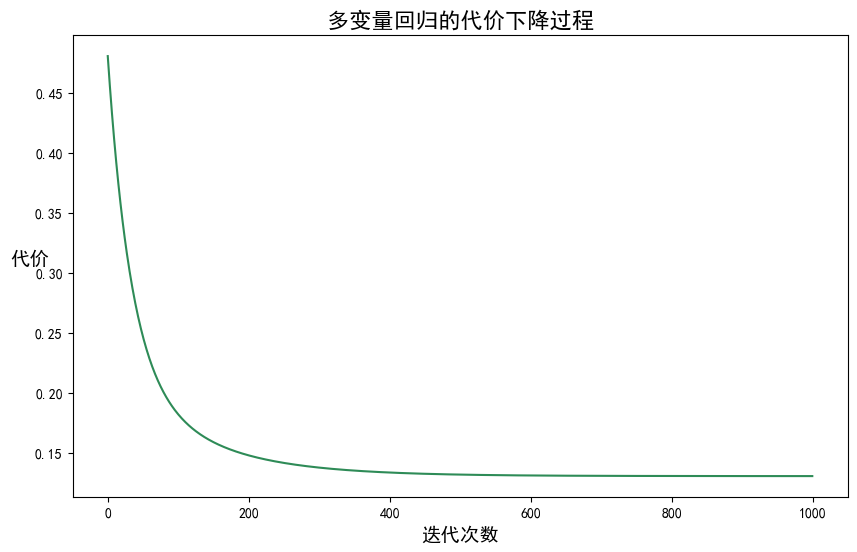

In [9]:
# Train the multivariate linear regression using the same gradient descent method
g2, cost2 = batch_gradient_descent(X2, y2, w2, alpha, iters)
print('Multi-variable parameters:', g2)
print('Multi-variable final cost:', compute_cost(X2, y2, g2))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.arange(iters), cost2, 'seagreen')
ax.set_xlabel('迭代次数', fontsize=14)
ax.set_ylabel('代价', fontsize=14, rotation=0)
ax.set_title('多变量回归的代价下降过程', fontsize=16)
plt.show()

## 4.9 Use sklearn linear regression

Use `LinearRegression` as a simple reference.

LinearRegression intercept: -3.895780878311852
LinearRegression coef: [1.19303364]
LinearRegression R^2: 0.7020315537841397


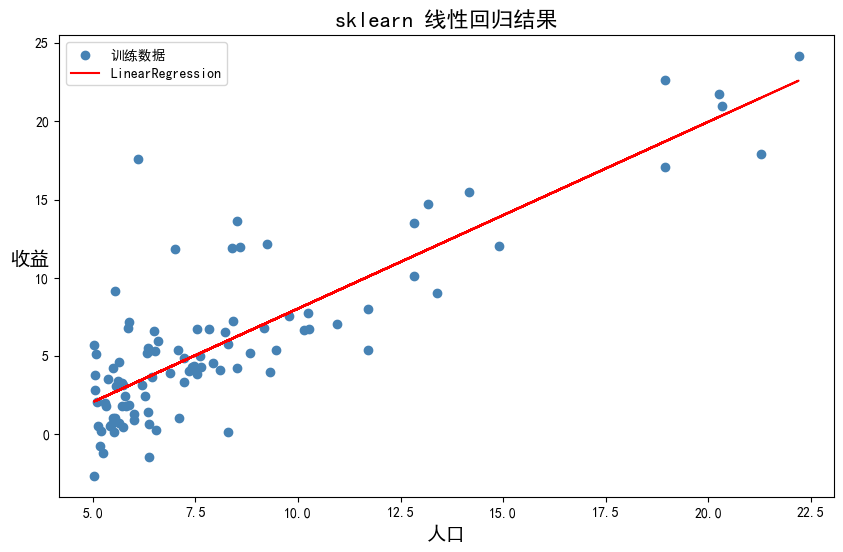

In [10]:
#  sklearn 
X1_sklearn = data1[['人口']]
y1_sklearn = data1['收益']

lr_model = LinearRegression()
lr_model.fit(X1_sklearn, y1_sklearn)
print('LinearRegression intercept:', lr_model.intercept_)
print('LinearRegression coef:', lr_model.coef_)
print('LinearRegression R^2:', lr_model.score(X1_sklearn, y1_sklearn))

pred_lr = lr_model.predict(X1_sklearn)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(data1['人口'], data1['收益'], label='训练数据', color='steelblue')
ax.plot(data1['人口'], pred_lr, 'r', label='LinearRegression')
ax.legend(loc=2)
ax.set_xlabel('人口', fontsize=14)
ax.set_ylabel('收益', fontsize=14, rotation=0)
ax.set_title('sklearn 线性回归结果', fontsize=16)
plt.show()

## 4.10 Compare Ridge and Lasso

Compare two regularized regression models in a simple way.

Ridge intercept: -3.889014391929985
Ridge coef: [1.1922044]
Lasso intercept: -3.8407274679766417
Lasso coef: [1.18628674]


d:\kaifagongju\Anaconda\envs\DL\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
d:\kaifagongju\Anaconda\envs\DL\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


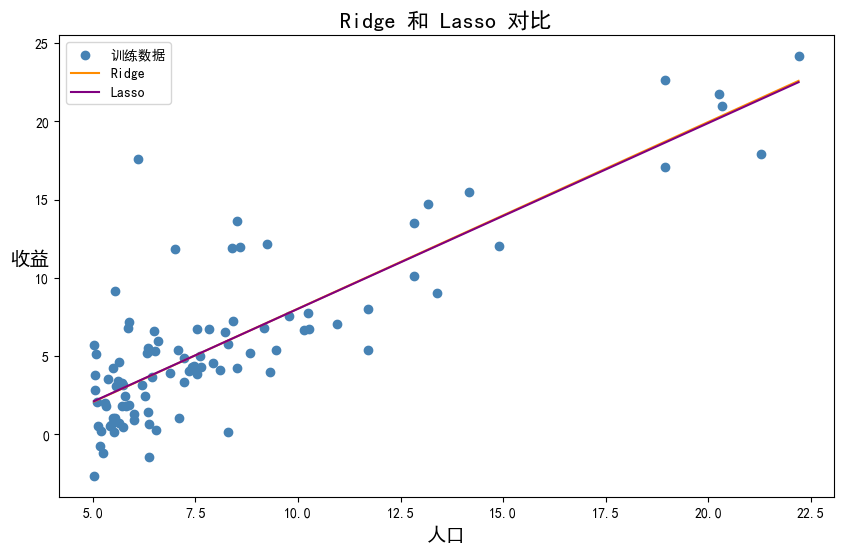

In [11]:
# use Ridge and Lasso to compare the efficiency
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X1_sklearn, y1_sklearn)
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X1_sklearn, y1_sklearn)

print('Ridge intercept:', ridge_model.intercept_)
print('Ridge coef:', ridge_model.coef_)
print('Lasso intercept:', lasso_model.intercept_)
print('Lasso coef:', lasso_model.coef_)

x_sorted = np.sort(data1['人口'].values)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(data1['人口'], data1['收益'], label='训练数据', color='steelblue')
ax.plot(x_sorted, ridge_model.predict(x_sorted.reshape(-1, 1)), label='Ridge', color='darkorange')
ax.plot(x_sorted, lasso_model.predict(x_sorted.reshape(-1, 1)), label='Lasso', color='purple')
ax.legend(loc=2)
ax.set_xlabel('人口', fontsize=14)
ax.set_ylabel('收益', fontsize=14, rotation=0)
ax.set_title('Ridge 和 Lasso 对比', fontsize=16)
plt.show()

## 4.11 Tune Ridge alpha with cross-validation

Try different alpha values and see which one works better.

Best alpha: 0.001
Best CV RMSE: 3.1311785021564136


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

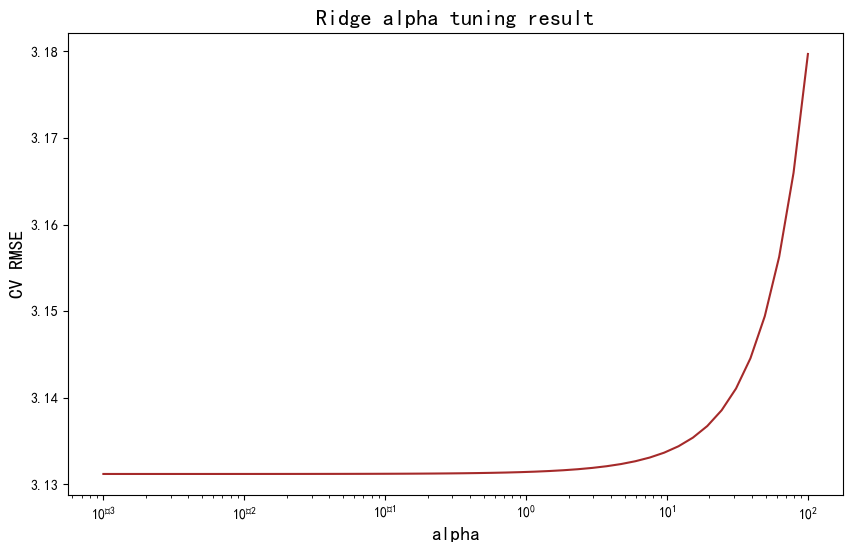

In [12]:
# 通过交叉验证寻找更合适的 Ridge alpha 参数
alphas = np.logspace(-3, 2, 50)
test_scores = []

for alpha_value in alphas:
    clf = Ridge(alpha=alpha_value)
    score = np.sqrt(-cross_val_score(clf, X1_sklearn, y1_sklearn, cv=5, scoring='neg_mean_squared_error'))
    test_scores.append(np.mean(score))

best_idx = int(np.argmin(test_scores))
print('Best alpha:', alphas[best_idx])
print('Best CV RMSE:', test_scores[best_idx])

plt.figure(figsize=(10, 6))
plt.semilogx(alphas, test_scores, color='brown')
plt.xlabel('alpha', fontsize=14)
plt.ylabel('CV RMSE', fontsize=14)
plt.title('Ridge alpha tuning result', fontsize=16)
plt.show()

## 4.12 Solve the model by least squares

Use the closed-form least squares solution for comparison.

In [13]:
# 用最小二乘法直接求线性回归的闭式解
def least_squares_method(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

lsm_w = least_squares_method(X1, y1)
print('Least squares parameters:')
print(lsm_w)

Least squares parameters:
[[-3.89578088]
 [ 1.19303364]]


# Part 5. Simple Summary

This small practice shows the basic workflow of linear regression. The scatter plot, fitted line, and cost curve help me see how the model learns from data.

For the multi-variable part, standardization makes training more stable. The results from gradient descent, sklearn, and least squares are close overall, so the implementation is basically reasonable.

In [14]:
# 汇总关键结果，方便最后分析实验结论
summary = {
    'single_variable_final_cost': float(compute_cost(X1, y1, g1)),
    'multi_variable_final_cost': float(compute_cost(X2, y2, g2)),
    'linear_regression_r2': float(lr_model.score(X1_sklearn, y1_sklearn)),
    'best_ridge_alpha': float(alphas[best_idx]),
    'best_ridge_cv_rmse': float(test_scores[best_idx]),
}
summary

{'single_variable_final_cost': 4.515955503078914,
 'multi_variable_final_cost': 0.13070336960771892,
 'linear_regression_r2': 0.7020315537841397,
 'best_ridge_alpha': 0.001,
 'best_ridge_cv_rmse': 3.1311785021564136}